# 04 — Indonesia Nationwide Agroclimatic Dataset (DS04)
**TaniAdapt Project — Agroclimate Benchmark & Extreme Indicators**
**Fase:** Phase 3 (Discovery & Acquisition) + Phase 4 (Dataset Quality Audit)

- **Sumber Resmi:** [Mendeley Data DOI: 10.17632/3pfbdbzfff.1](https://doi.org/10.17632/3pfbdbzfff.1)
- **Basis Data:** Open-Meteo Historical Weather / ERA5-Seamless (612 grid points, 2016–2025)
- **Peran di TaniAdapt:** Referensi pembanding indikator agroklimat ekstrem (CDD, CWD, GDD).


In [1]:
from pathlib import Path
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name.lower() == "notebook" else CWD
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "DS04_indonesia_agroclimatic"
FIGURES_DIR = PROJECT_ROOT / "reports" / "dataset_audit" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)
print("Raw Data Dir:", RAW_DIR)


Project Root: C:\CODING\research_taniAdapt
Raw Data Dir: C:\CODING\research_taniAdapt\data\raw\DS04_indonesia_agroclimatic


## Phase 3 & 4 — Audit 612 Titik Grid & Definisi Indikator Ekstrem
Membaca katalog titik grid spasial terestrial Indonesia dan definisi 12 indikator agroklimat.


In [2]:
df_grid = pd.read_csv(RAW_DIR / "grid_points.csv")
df_def = pd.read_csv(RAW_DIR / "indicator_definitions.csv", encoding="latin1")

print("Total Titik Grid Terestrial Indonesia:", len(df_grid))
print("Total Definisi Indikator Agroklimat  :", len(df_def))

# Titik potong khusus wilayah Jawa Barat (-7.9 s.d. -5.8 N, 106.3 s.d. 109.0 E)
df_jabar_grid = df_grid[(df_grid['latitude'] >= -7.9) & (df_grid['latitude'] <= -5.8) &
                        (df_grid['longitude'] >= 106.3) & (df_grid['longitude'] <= 109.0)]
print(f"\nJumlah Titik Grid Melingkupi Jawa Barat: {len(df_jabar_grid)} titik")


Total Titik Grid Terestrial Indonesia: 612
Total Definisi Indikator Agroklimat  : 12

Jumlah Titik Grid Melingkupi Jawa Barat: 14 titik


## Kamus 12 Indikator Agroklimat Turunan
Daftar indikator agroklimat harian yang dikalkulasikan untuk pemodelan stres iklim.


In [3]:
display(df_def[["variable", "unit", "description"]])


,variable,unit,description
0,rainfall_7d,mm,Sum of precipitation_sum over the current day ...
1,rainfall_30d,mm,Sum of precipitation_sum over the current day ...
2,rainfall_90d,mm,Sum of precipitation_sum over the current day ...
3,rainy_days_30d,days,Number of days with precipitation_sum >= 1.0 m...
4,rainy_days_90d,days,Number of days with precipitation_sum >= 1.0 m...
5,max_daily_rainfall_30d,mm,Maximum precipitation_sum over the current day...
6,consecutive_dry_days,days,Number of consecutive days with precipitation_...
7,temperature_range,°C,Difference between temperature_2m_max and temp...
8,rolling_temperature_mean_7d,°C,Mean of temperature_2m_mean over the current d...
9,cumulative_et0_30d,mm,Sum of et0_fao_evapotranspiration over the cur...


## Visualisasi Diagnostik & Peta Sebaran Spasial (PNG)
Memetakan sebaran 612 titik grid terestrial Indonesia dengan penanda khusus 14 titik di wilayah daratan Jawa Barat.


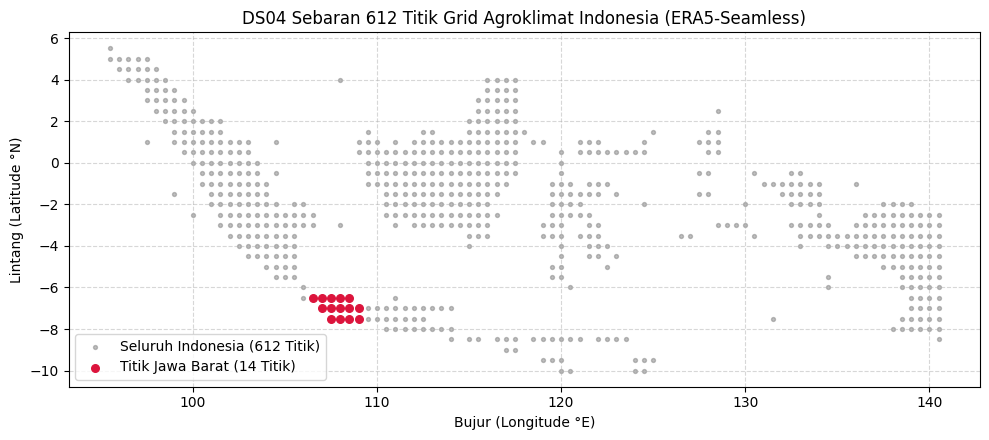

Gambar PNG berhasil disimpan ke: C:\CODING\research_taniAdapt\reports\dataset_audit\figures\ds04_agroclimate_grid_map.png


In [4]:
plt.figure(figsize=(10, 4.5))
plt.scatter(df_grid['longitude'], df_grid['latitude'], c='grey', s=8, alpha=0.5, label='Seluruh Indonesia (612 Titik)')
plt.scatter(df_jabar_grid['longitude'], df_jabar_grid['latitude'], c='crimson', s=30, label=f'Titik Jawa Barat ({len(df_jabar_grid)} Titik)')

plt.title("DS04 Sebaran 612 Titik Grid Agroklimat Indonesia (ERA5-Seamless)")
plt.xlabel("Bujur (Longitude °E)")
plt.ylabel("Lintang (Latitude °N)")
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

png_out = FIGURES_DIR / "ds04_agroclimate_grid_map.png"
plt.savefig(png_out, dpi=150)
plt.show()
print(f"Gambar PNG berhasil disimpan ke: {png_out}")


## Executive Audit Scorecard


In [5]:
scorecard = pd.DataFrame([
    {"Dimensi Audit": "Dataset Identifier", "Hasil & Evaluasi": "DS04 — Indonesia Nationwide Agroclimatic Dataset"},
    {"Dimensi Audit": "Penerbit & Sumber", "Hasil & Evaluasi": "Elsevier / Mendeley Data (DOI: 10.17632/3pfbdbzfff.1)"},
    {"Dimensi Audit": "Cakupan Wilayah", "Hasil & Evaluasi": "612 Titik Grid Daratan Indonesia (14 Titik Jawa Barat)"},
    {"Dimensi Audit": "Rentang Periode", "Hasil & Evaluasi": "2016 s.d. 2025 (Harian)"},
    {"Dimensi Audit": "Format Data Tersedia", "Hasil & Evaluasi": "Parquet (60 MB) + CSV (Tabel Grid & Definisi)"},
    {"Dimensi Audit": "Indikator Kunci", "Hasil & Evaluasi": "Consecutive Dry Days (CDD), CWD, Rainfall 7d/30d/90d, Temperature Range"},
    {"Dimensi Audit": "Peran di TaniAdapt", "Hasil & Evaluasi": "Agroclimate Reference & Comparison Backbone"},
    {"Dimensi Audit": "Status Disposisi", "Hasil & Evaluasi": "PASS (Referensi indikator iklim ekstrem nasional)"},
    {"Dimensi Audit": "Batasan Kritis", "Hasil & Evaluasi": "Resolusi spasial 0,5° (~55 km) lebih kasar dibanding AgERA5 0,1° (~10 km)."}
])

display(scorecard)


,Dimensi Audit,Hasil & Evaluasi
0,Dataset Identifier,DS04 — Indonesia Nationwide Agroclimatic Dataset
1,Penerbit & Sumber,Elsevier / Mendeley Data (DOI: 10.17632/3pfbdb...
2,Cakupan Wilayah,612 Titik Grid Daratan Indonesia (14 Titik Jaw...
3,Rentang Periode,2016 s.d. 2025 (Harian)
4,Format Data Tersedia,Parquet (60 MB) + CSV (Tabel Grid & Definisi)
5,Indikator Kunci,"Consecutive Dry Days (CDD), CWD, Rainfall 7d/3..."
6,Peran di TaniAdapt,Agroclimate Reference & Comparison Backbone
7,Status Disposisi,PASS (Referensi indikator iklim ekstrem nasional)
8,Batasan Kritis,"Resolusi spasial 0,5° (~55 km) lebih kasar dib..."
